# __Patrón creacional - Factory Method__

Para el primer patrón, usaré de escenario un peaje, debido a que todos los carriles hacen lo mismo: leen la placa, cobran según la categoría del vehículo, entregan un comprobante y suben la talanquera. Lo único que cambia de un carril a otro es el comprobante. El de efectivo imprime un tiquete de papel, el electrónico manda un comprobante digital al sistema del TAG y el empresarial genera una factura con el NIT de la transportadora.

Factory Method sirve justo para eso: dejar la decisión de qué objeto se crea en manos de las subclases, sin que el código que lo usa sepa qué clase concreta le devolvieron.

## Sin patrón

Lo primero que se me ocurrió fue guardar el tipo de carril en un string y resolver el comprobante con un if/elif adentro de la caseta.

Así la caseta termina sabiendo cómo se arma y cómo se entrega cada uno de los tres formatos, y cada carril nuevo obliga a volver a abrir la clase. De paso, el NIT solo lo usa el carril empresarial pero le toca vivir ahí, en todas las casetas.

In [1]:
class Caseta:
    def __init__(self, nombre, tipo):
        self.nombre = nombre
        self.tipo = tipo          # "efectivo", "electronica" o "empresarial"
        self.nit_empresa = None   # solo lo usa el carril empresarial... pero vive aqui igual

    def atender(self, placa, categoria, valor):
        print("[" + self.nombre + "] Vehiculo " + placa + " (categoria " + categoria + ") paga $" + str(valor))

        # AQUI ESTA EL PROBLEMA: la caseta tiene que saber como se arma
        # Y como se entrega CADA tipo de comprobante
        if self.tipo == "efectivo":
            print("   Imprimiendo en impresora termica...")
            print("   TIQUETE No 0001 | placa " + placa + " | cat " + categoria + " | $" + str(valor))
        elif self.tipo == "electronica":
            print("   Enviando comprobante al sistema del TAG...")
            print("   {'placa': '" + placa + "', 'categoria': '" + categoria + "', 'valor': " + str(valor) + "}")
        elif self.tipo == "empresarial":
            print("   Generando factura electronica...")
            print("   FACTURA PE-" + placa + " | NIT " + str(self.nit_empresa) + " | $" + str(valor))
        else:
            # y si llega un tipo nuevo... no pasa nada, se cae en silencio
            print("   (!) No se como emitir el comprobante de este tipo de caseta")

        print("   Talanquera arriba\n")

caseta1 = Caseta("Carril 1", "efectivo")
caseta1.atender("ABC123", "I", 11000)

caseta2 = Caseta("Carril 2", "electronica")
caseta2.atender("XYZ789", "I", 11000)

caseta3 = Caseta("Carril 3", "empresarial")
caseta3.nit_empresa = "900123456-7"
caseta3.atender("TRK555", "III", 30000)

[Carril 1] Vehiculo ABC123 (categoria I) paga $11000
   Imprimiendo en impresora termica...
   TIQUETE No 0001 | placa ABC123 | cat I | $11000
   Talanquera arriba

[Carril 2] Vehiculo XYZ789 (categoria I) paga $11000
   Enviando comprobante al sistema del TAG...
   {'placa': 'XYZ789', 'categoria': 'I', 'valor': 11000}
   Talanquera arriba

[Carril 3] Vehiculo TRK555 (categoria III) paga $30000
   Generando factura electronica...
   FACTURA PE-TRK555 | NIT 900123456-7 | $30000
   Talanquera arriba



Y esto es lo que pasa el día que el peaje habilita el pago por app móvil:

In [2]:
caseta4 = Caseta("Carril 4", "app_movil")
caseta4.atender("MOT001", "I", 5500)
print(">>> El vehiculo paso sin comprobante y el codigo no fallo.") #Aquí está el bug

[Carril 4] Vehiculo MOT001 (categoria I) paga $5500
   (!) No se como emitir el comprobante de este tipo de caseta
   Talanquera arriba

>>> El vehiculo paso sin comprobante y el codigo no fallo.


## Con patrón

Separo dos cosas. Por un lado los comprobantes: `Comprobante` y sus implementaciones. Por otro las casetas: `Caseta`, con un método `crear_comprobante` que no hace nada, y una subclase por carril que lo sobrescribe.

Lo importante es que `crear_comprobante` no decide nada, es un hueco que cada subclase llena. Ahí está la diferencia con una función que reparte con if/elif: acá el punto de variación se extiende heredando, no editando.

Uso clases normales con `raise NotImplementedError` en vez de ABC para no complicar el ejemplo. El rol de interfaz se cumple igual, si una subclase se olvida del método el error sale de una.

In [3]:
class Comprobante:
    def emitir(self):
        raise NotImplementedError("Cada comprobante decide como se emite")


class TiqueteImpreso(Comprobante):
    def __init__(self, placa, categoria, valor):
        self.placa = placa
        self.categoria = categoria
        self.valor = valor

    def emitir(self):
        print("   Imprimiendo en impresora termica...")
        print(f"   TIQUETE No 0001 | placa {self.placa} | cat {self.categoria} | ${self.valor}")


class ComprobanteDigital(Comprobante):
    def __init__(self, placa, categoria, valor, id_tag):
        self.placa = placa
        self.categoria = categoria
        self.valor = valor
        self.id_tag = id_tag

    def emitir(self):
        print("   Enviando comprobante al sistema del TAG...")
        print(f"   TAG {self.id_tag} | placa {self.placa} | cat {self.categoria} | ${self.valor}")


class FacturaElectronica(Comprobante):
    def __init__(self, placa, categoria, valor, nit):
        self.placa = placa
        self.categoria = categoria
        self.valor = valor
        self.nit = nit

    def emitir(self):
        print("   Generando factura electronica y enviandola a la DIAN...")
        print(f"   FACTURA PE-{self.placa} | NIT {self.nit} | cat {self.categoria} | ${self.valor}")


print("Productos definidos:", Comprobante.__name__, TiqueteImpreso.__name__,
      ComprobanteDigital.__name__, FacturaElectronica.__name__)

Productos definidos: Comprobante TiqueteImpreso ComprobanteDigital FacturaElectronica


In [4]:
class Caseta:
    def __init__(self, nombre):
        self.nombre = nombre
        self.vehiculos_atendidos = 0

    # <<< ESTE ES EL METODO DE FABRICA >>>
    # No hay ningun if/elif aqui: son las SUBCLASES las que lo sobrescriben.
    def crear_comprobante(self, placa, categoria, valor):
        raise NotImplementedError("Cada caseta debe decir que comprobante entrega")

    # Algoritmo comun: igual para TODOS los carriles, hoy y en el futuro.
    def atender(self, placa, categoria, valor):
        print(f"[{self.nombre}] Vehiculo {placa} (categoria {categoria}) paga ${valor}")
        comprobante = self.crear_comprobante(placa, categoria, valor)   # <-- punto de extension
        comprobante.emitir()
        self.vehiculos_atendidos = self.vehiculos_atendidos + 1
        print("   Talanquera arriba\n")



class CasetaEfectivo(Caseta):
    def crear_comprobante(self, placa, categoria, valor):
        return TiqueteImpreso(placa, categoria, valor)


class CasetaElectronica(Caseta):
    def __init__(self, nombre, id_tag):
        super().__init__(nombre)
        self.id_tag = id_tag   # dato propio de este carril

    def crear_comprobante(self, placa, categoria, valor):
        return ComprobanteDigital(placa, categoria, valor, self.id_tag)


class CasetaEmpresarial(Caseta):
    def __init__(self, nombre, nit):
        super().__init__(nombre)
        self.nit = nit         # dato propio de este carril

    def crear_comprobante(self, placa, categoria, valor):
        return FacturaElectronica(placa, categoria, valor, self.nit)


print("Creadores definidos correctamente")

Creadores definidos correctamente


El cliente recorre carriles completamente distintos llamando siempre a `atender()`, sin preguntar de qué tipo es cada uno:

In [5]:
carriles = [
    CasetaEfectivo("Carril 1"),
    CasetaElectronica("Carril 2", id_tag="TAG-4471"),
    CasetaEmpresarial("Carril 3", nit="900123456-7"),
]

vehiculos = [("ABC123", "I", 11000), ("XYZ789", "I", 11000), ("TRK555", "III", 30000)]

# El cliente trata a todos los carriles igual: polimorfismo puro, cero if/elif
for carril, vehiculo in zip(carriles, vehiculos):
    placa, categoria, valor = vehiculo
    carril.atender(placa, categoria, valor)

[Carril 1] Vehiculo ABC123 (categoria I) paga $11000
   Imprimiendo en impresora termica...
   TIQUETE No 0001 | placa ABC123 | cat I | $11000
   Talanquera arriba

[Carril 2] Vehiculo XYZ789 (categoria I) paga $11000
   Enviando comprobante al sistema del TAG...
   TAG TAG-4471 | placa XYZ789 | cat I | $11000
   Talanquera arriba

[Carril 3] Vehiculo TRK555 (categoria III) paga $30000
   Generando factura electronica y enviandola a la DIAN...
   FACTURA PE-TRK555 | NIT 900123456-7 | cat III | $30000
   Talanquera arriba



Ahora sí el carril de la app. Escribo un producto nuevo y un creador nuevo, y no toco nada de lo anterior:

In [6]:
class ComprobantePorCorreo(Comprobante):
    def __init__(self, placa, categoria, valor, correo):
        self.placa = placa
        self.categoria = categoria
        self.valor = valor
        self.correo = correo

    def emitir(self):
        print("   Enviando comprobante por correo electronico...")
        print(f"   Para: {self.correo} | placa {self.placa} | cat {self.categoria} | ${self.valor}")


class CasetaAppMovil(Caseta):
    def __init__(self, nombre, correo_usuario):
        super().__init__(nombre)
        self.correo_usuario = correo_usuario

    def crear_comprobante(self, placa, categoria, valor):
        return ComprobantePorCorreo(placa, categoria, valor, self.correo_usuario)


carril4 = CasetaAppMovil("Carril 4", "conductor@correo.com")
carril4.atender("MOT001", "I", 5500)

print(">>> Lineas modificadas de las clases anteriores: 0")
print(">>> Ahora el comprobante SI se emite, y el metodo atender() nunca se toco.")

[Carril 4] Vehiculo MOT001 (categoria I) paga $5500
   Enviando comprobante por correo electronico...
   Para: conductor@correo.com | placa MOT001 | cat I | $5500
   Talanquera arriba

>>> Lineas modificadas de las clases anteriores: 0
>>> Ahora el comprobante SI se emite, y el metodo atender() nunca se toco.


### __IMAGEN DEL UML (El codigo está adjunto abajo de esto)__
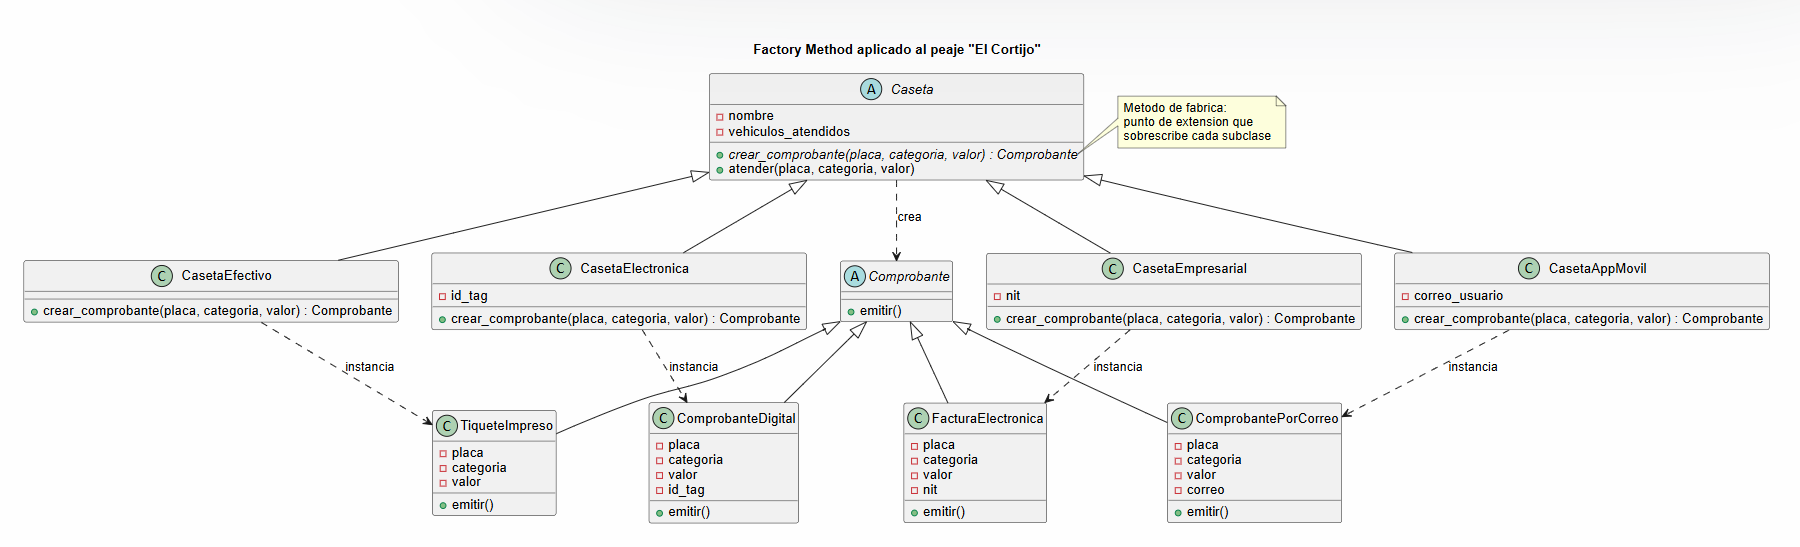

## UML

```plantuml
@startuml
title Factory Method aplicado al peaje "El Cortijo"

' ---------- PRODUCT ----------
abstract class Comprobante {
    + emitir()
}

class TiqueteImpreso {
    - placa
    - categoria
    - valor
    + emitir()
}

class ComprobanteDigital {
    - placa
    - categoria
    - valor
    - id_tag
    + emitir()
}

class FacturaElectronica {
    - placa
    - categoria
    - valor
    - nit
    + emitir()
}

class ComprobantePorCorreo {
    - placa
    - categoria
    - valor
    - correo
    + emitir()
}

' ---------- CREATOR ----------
abstract class Caseta {
    - nombre
    - vehiculos_atendidos
    + {abstract} crear_comprobante(placa, categoria, valor) : Comprobante
    + atender(placa, categoria, valor)
}

class CasetaEfectivo {
    + crear_comprobante(placa, categoria, valor) : Comprobante
}

class CasetaElectronica {
    - id_tag
    + crear_comprobante(placa, categoria, valor) : Comprobante
}

class CasetaEmpresarial {
    - nit
    + crear_comprobante(placa, categoria, valor) : Comprobante
}

class CasetaAppMovil {
    - correo_usuario
    + crear_comprobante(placa, categoria, valor) : Comprobante
}

Comprobante <|-- TiqueteImpreso
Comprobante <|-- ComprobanteDigital
Comprobante <|-- FacturaElectronica
Comprobante <|-- ComprobantePorCorreo

Caseta <|-- CasetaEfectivo
Caseta <|-- CasetaElectronica
Caseta <|-- CasetaEmpresarial
Caseta <|-- CasetaAppMovil

Caseta ..> Comprobante : crea

CasetaEfectivo ..> TiqueteImpreso : instancia
CasetaElectronica ..> ComprobanteDigital : instancia
CasetaEmpresarial ..> FacturaElectronica : instancia
CasetaAppMovil ..> ComprobantePorCorreo : instancia

note right of Caseta::crear_comprobante
  Metodo de fabrica:
  punto de extension que
  sobrescribe cada subclase
end note
@enduml
```

## ¿Por qué Factory Method y no otro?

Lo que varía en mi problema es una sola cosa, qué clase de comprobante se instancia, mientras el resto de la atención queda igual. Con eso se caen casi todos los demás creacionales.

Abstract Factory tendría sentido si cada carril tuviera que crear una familia entera de objetos que deben ser coherentes entre sí, por ejemplo comprobante + reporte contable + formato de pantalla, todos del mismo estilo. Como acá solo varía un producto, me quedaría una interfaz de fábrica con un único método, que es más ruido que ayuda. Si mañana piden lo del reporte la migración es corta, porque la jerarquía ya quedó hecha.

Builder es para objetos que se arman por pasos y con muchas opciones. Mis comprobantes se crean de una con tres o cuatro datos.

Prototype clona objetos que son caros de construir, y acá cada comprobante tiene que salir distinto de todas formas porque cambian la placa y el valor, así que clonar no ahorra nada. Singleton ni siquiera va en la misma dirección: se crea un comprobante por cada carro que pasa, una instancia única sería justo lo contrario.